In [1]:
#импортики
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.cluster import DBSCAN

import random
from math import sqrt
from math import cos
from math import sin

In [2]:
#константики
CLUST_N = 2
POINT_N = 200
KNBR_N = 5

In [3]:
import numpy as np

#расстояние от точки до точки
def euclidean(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

# Поиск соседей в радиусе eps
def region_query(data, point_id, eps):
    neighbors = []
    for i in range(len(data)):
        if euclidean(data[point_id], data[i]) <= eps:
            neighbors.append(i)
    return neighbors


# Расширение кластера
def expand_cluster(data, labels, point_id, neighbors, cluster_id, eps, min_samples):
    labels[point_id] = cluster_id

    queue = list(neighbors)
    i = 0

    while i < len(queue):
        n_point = queue[i]

        # если точка была шумом, то теперь часть кластера
        if labels[n_point] == -1:
            labels[n_point] = cluster_id

        # если не посещена
        if labels[n_point] == -2:
            labels[n_point] = cluster_id

            n_neighbors = region_query(data, n_point, eps)

            # если это ядро, то расширяем
            if len(n_neighbors) >= min_samples:
                for nn in n_neighbors:
                    if nn not in queue:
                        queue.append(nn)

        i += 1


def dbscan(data, eps=0.2, min_samples=5):
    n = len(data)

    # -2 = не посещена
    # -1 = шум
    labels = np.full(n, -2)

    cluster_id = 0

    for point_id in range(n):
        if labels[point_id] != -2:
            continue

        neighbors = region_query(data, point_id, eps)

        # если недостаточно соседей, шум
        if len(neighbors) < min_samples:
            labels[point_id] = -1
        else:
            expand_cluster(
                data,
                labels,
                point_id,
                neighbors,
                cluster_id,
                eps,
                min_samples
            )
            cluster_id += 1

    return labels

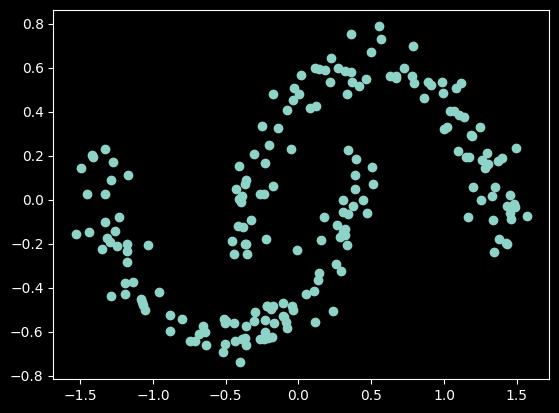

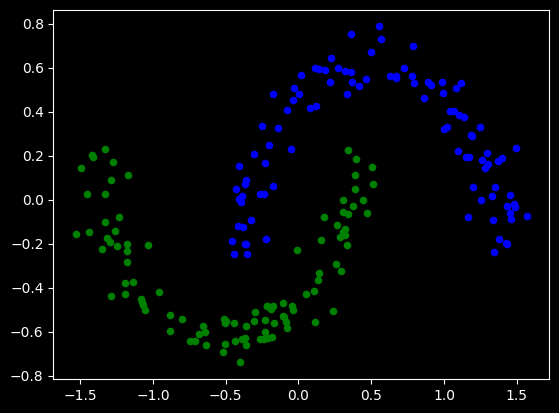

In [4]:

data = np.array([[0.0, 0.0] for i in range(POINT_N)])
targ = np.array([2 for i in range(POINT_N)])

for i in range(POINT_N):
		f = 3.14 * random.random()
		r = 0.2 * random.normalvariate(0.0, 0.4) + 0.9
		if random.random() < 0.5:
			targ[i] = 0
			data[i,0] = 0.5 + r * cos(f)
			data[i,1] = -0.25 + r * sin(f)
		else:
			targ[i] = 1
			data[i,0] = -0.5 + r * cos(f)
			data[i,1] = 0.25 - r * sin(f)

plt.scatter(data[:,0], data[:,1])
plt.show()

db = dbscan(data, eps=0.20, min_samples=8)

for i in range(POINT_N):
    if db[i] == 0:
        plt.scatter(data[i,0], data[i,1], c='blue', s=20)
    elif db[i] == 1:
        plt.scatter(data[i,0], data[i,1], c='green', s=20)
    else:
        plt.scatter(data[i,0], data[i,1], c='red', s=20)
plt.show()


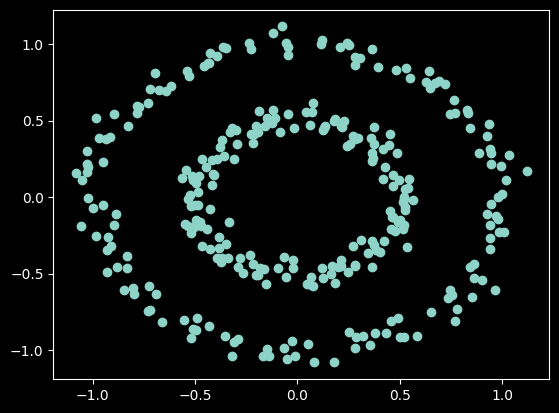

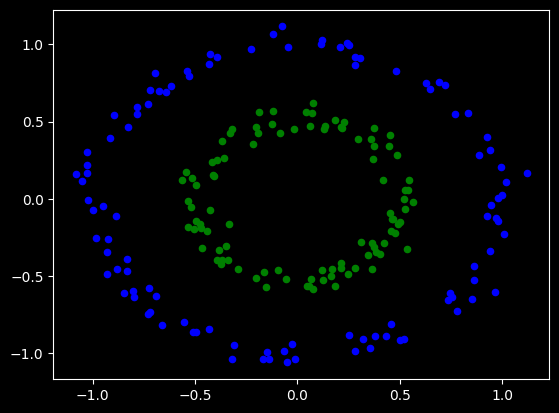

In [5]:
from sklearn.datasets import make_circles

data, _ = make_circles(n_samples=300, factor=0.5, noise=0.05)
plt.scatter(data[:,0], data[:,1])
plt.show()

db = dbscan(data, eps=0.20, min_samples=5)

for i in range(POINT_N):
    if db[i] == 0:
        plt.scatter(data[i,0], data[i,1], c='blue', s=20)
    elif db[i] == 1:
        plt.scatter(data[i,0], data[i,1], c='green', s=20)
    else:
        plt.scatter(data[i,0], data[i,1], c='red', s=20)
plt.show()